## 정재문_머신러닝 파이프라인

### 1. 문제 정의 및 목표 설정 (미션 개요)

* 해결하고자 하는 문제 정의
* 최종 산출물 목표 설정 (예측, 분류, 추천 등)

### 2. 데이터 입력 및 EDA

* 데이터 로딩 및 기본 구조 확인 (shape, columns, types)
* 결측치, 이상치 확인
* 기초 통계량 확인 (평균, 표준편차, 분포 등)
* **상관관계 분석 (Heatmap, Scatter 등)**
* 패턴 탐색 (요일별, 계절별, 시간대별 등)

### 3. 데이터 전처리

* 결측치 처리
* 이상치 제거 및 대체
* 범주형 인코딩 / 수치형 스케일링
* 변수 변환 및 파생 변수 생성
* Train / Test 데이터 분리

### 4. 심화 분석 (드릴 다운)

* 특정 구간별/조건별 심층 분석
* 예:

  * 온도가 5 이하일 때 수요 변화
  * 주말과 공휴일 비교
  * 특정 월/계절별 패턴

### 5. 모델링

* 베이스라인 모델 설정 (예: LinearRegression)
* 다양한 모델 학습 (DecisionTree, RandomForest, XGBoost 등)
* 성능 평가 (RMSE, RMSLE, Accuracy 등)

### 6. 결과 시각화

* Feature Importance 시각화
* 예측값 vs 실제값 비교
* Error 분석 (잔차 플롯 등)

### 7. 결과 생성 및 해석

* 최종 지표 정리 (테이블/그래프)
* 주요 인사이트 도출
* 비즈니스적/실제 문제와 연결

## 0. 한글 설치

In [ ]:
import matplotlib.font_manager as fm

# 설치된 폰트 전체 목록 보기
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'Nanum' in f or 'Malgun' in f or 'AppleGothic' in f:
        print(f)

/Users/moon/Library/Fonts/NanumGothic-ExtraBold.ttf
/Users/moon/Library/Fonts/NanumSquareB.otf
/Users/moon/Library/Fonts/NanumGothic-Regular.ttf
/Users/moon/Library/Fonts/NanumSquareOTF_acEB.otf
/Users/moon/Library/Fonts/NanumBarunpenR.otf
/Users/moon/Library/Fonts/NanumMyeongjoBold.otf
/Users/moon/Library/Fonts/NanumSquareNeoOTF-Lt.otf
/Users/moon/Library/Fonts/NanumMyeongjoBold.ttf
/Users/moon/Library/Fonts/NanumMyeongjoEcoBold.otf
/Users/moon/Library/Fonts/NanumSquareOTF_acL.otf
/Users/moon/Library/Fonts/NanumSquareRoundOTFL.otf
/Users/moon/Library/Fonts/NanumBarunGothic-YetHangul.ttf
/Users/moon/Library/Fonts/NanumSquareNeo-bRg.ttf
/Users/moon/Library/Fonts/NanumSquareRoundEB.ttf
/Users/moon/Library/Fonts/NanumHumanEL.ttf
/Users/moon/Library/Fonts/NanumSquareR.ttf
/Users/moon/Library/Fonts/NanumGothicEcoBold.otf
/Users/moon/Library/Fonts/NanumGothicEco.ttf
/Users/moon/Library/Fonts/NanumSquareNeoOTF-Bd.otf
/Users/moon/Library/Fonts/NanumHumanBold.ttf
/Users/moon/Library/Fonts/Nanum

In [ ]:
#한글 설치 ㄱㄱ

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

# 나눔바른고딕 경로 지정
path = '/Users/moon/Library/Fonts/NanumBarunGothic.ttf'

# 폰트 등록
fm.fontManager.addfont(path)
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)   # matplotlib 기본 폰트로 지정

## 0. 문제 해결 파이프라인 (숫자니까 회귀)

1. 미션 개요 (문제 정의 및 목표 설정)  
2. 기본 데이터 입력 및 EDA   
3. 전처리  
4. 드릴 다운 (할 수 있는게 있다면?)
5. 모델링  
6. 결과 시각화 (Feature Importance)  
7. 결과 생성  



## 1. 📌 미션 개요 🚲

앞선 토픽에서 배운 내용을 바탕으로 프로그래밍 예제 문제를 풀어보는 미션입니다.
스프린트 미션 유형과 제출 방식은 **스프린트 미션 안내 및 제출 가이드**를 참고하세요 😊

이번 미션에서는 **자전거 대여 시스템 데이터를 분석**합니다.

---

### 🎯 미션 배경

여러분은 자전거 대여 시스템의 운영 담당자라고 가정합니다. 목표는:

* 자전거 **대여 패턴 분석**
* 자전거 **배치 및 운영 전략 최적화**
* 자전거 **수요 예측**

이를 통해 시스템 효율성을 높이고, 사용자 만족도를 증가시키는 것이 이번 미션의 핵심입니다.

**최종 목표**: 예측 성능 지표인 **RMSLE (Root Mean Squared Logarithmic Error)** 값을 최대한 낮추는 것.

---

### 📊 RMSLE란?

* **정의**: 예측 값과 실제 값의 차이를 로그 변환하여 계산한 뒤, 그 차이의 제곱 평균의 제곱근을 구한 값.
* **공식**:

$$
RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(p_i+1) - \log(a_i+1)\right)^2}
$$

* $n$: 데이터 포인트 수
* $p_i$: 예측 값
* $a_i$: 실제 값

#### ✅ 장점

* **안정성**: 0에 가까운 값도 로그 변환으로 안정적으로 처리 가능
* **과대평가 방지**: 예측 값이 실제보다 훨씬 크면 큰 패널티 부여 → 신뢰성 증가

---

### 📐 다른 지표와 비교

* **MAE**: 평균 절대 오차 (모든 오차를 동일하게 취급)
* **MSE**: 평균 제곱 오차 (큰 오차에 더 큰 패널티)
* **RMSE**: MSE의 제곱근 (원래 단위로 환원)
* **RMSLE**: 작은 값의 오차에 더 민감, 큰 값 과대평가 방지

---

### 📚 데이터 소개

* **train.csv**: 훈련 데이터 (count 포함)
* **test.csv**: 예측용 데이터 (casual, registered, count 없음)

#### 컬럼 설명

| 컬럼명        | 타입       | 설명                                         |
| ---------- | -------- | ------------------------------------------ |
| datetime   | datetime | 자전거 대여 시각 (예: 2011-01-01 00:00:00)         |
| season     | int      | 계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울)             |
| holiday    | int      | 공휴일 여부 (0: 평일, 1: 공휴일)                     |
| workingday | int      | 근무일 여부 (0: 주말/공휴일, 1: 근무일)                 |
| weather    | int      | 날씨 (1: 맑음, 2: 구름/안개, 3: 약간의 비/눈, 4: 폭우/폭설) |
| temp       | float    | 실측 온도 (°C)                                 |
| atemp      | float    | 체감 온도 (°C)                                 |
| humidity   | int      | 습도 (%)                                     |
| windspeed  | float    | 풍속 (m/s)                                   |
| casual     | int      | 비등록 사용자 대여 수                               |
| registered | int      | 등록 사용자 대여 수                                |
| count      | int      | 총 대여 수 (**목표 변수**)                         |

---

### 🔎 예시 분석 질문

* 특정 시간대의 자전거 대여 패턴은?
* 날씨 변수와 수요 간 상관관계는?
* 계절별 대여 패턴 차이는?
* 주말 vs 평일 수요 차이는?
* 수요 예측에 가장 중요한 변수는?
* 예측 모델을 기반으로 운영 전략을 제안할 수 있을까?

---

### 📑 제출 내용

1. **Colab Notebook** (분석 과정, 결과 포함)
2. **보고서** (가설, 분석 전개, 인사이트 포함)

---

### 📂 제출 방법

* 제출 폴더: **구글 드라이브 → 결과물 제출 폴더 → 미션3 폴더**
* 폴더명: `{팀명}_{성함}`
* 파일명 규칙:

  * `미션3_{팀명}_{성함}.pdf`
  * `미션3_{팀명}_{성함}.ipynb`

예시:

* `미션3_1팀_홍길동.pdf`
* `미션3_1팀_홍길동.ipynb`


## 2. 기본 데이터 입력 및 EDA (탐색적 데이터 분석)

### 2.1. 기본 데이터 입력

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error # 구글에 RMSLE 회귀 찾아봄

df_test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')

In [ ]:
# 1) 기본 데이터를 파악해봅니다.

print(df_train.info())
# 열의 전체 정보 (datetime, season, holiday, workingday, whether, temp, atemp, humidity, windspeed, casual, registered, count)
print(df_test.info())
# 열의 전체 정보 (datetime, season, holiday, workingday, whether, temp, atemp, humidity, windspeed) -> 세 개를 예측하는 결말이 될 수도?
print("\n\n\n\n")
print(f"결측치 결과입니다\n{df_train.isna().sum()}")      # 결측치

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6

In [ ]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


### 2.2 EDA

#### 📊 자전거 대여 데이터 1차 분석 결과

##### 1. 데이터 개요

* 전체 크기 10885행 x 12열
* 변수 유형

  * 숫자형 (int/float) :  11개
  * 범주형 (object) : 1개

##### 2. 결측치 현황

* 없음

##### 3. 주요 변수 통계 요약

`datetime`:2011년 1월 1일부터의 데이터

`season`: Aver<0.2 ➡️ 봄과 여름에 더 많이 대여를 함.

`holiday`: Aver=0.02 (Right-Skewed) ➡️ 공휴일에 비해 평일에 이용자수가 훨씬 많음. (vs. 1: 공휴일)

`workingday`: Aver=0.46 ➡️ 주말/공휴일에 사용이 많음. (vs. 0: 근무일)

`weather`: AVER=1.46 ➡️ 1.41 (Right-Skewed) ➡️ 맑은 날 사용이 더 많음

`temp`: 온도는 0\~41도 사이의 평균은 20.23, 따라서 4-32.4 도에 95% 가 들어감.

`atemp`: 체감온도는 실제 온도보다는 조금 더 높은 것을 알 수 있음.

`humidity`: 습도가 너무 낮을땐, 자전거 이용자가 적다. (아마.. 겨울?)

`windspeed`: Right-skewed data, 바람이 너무 많이 불때 (56.96)는 자전거 이용자가 적다.

`casual`: Aver=49 (Right-skewed) : 평균과 표준편차 사이즈가 거의 같음. 이용자수의 변화폭이 큰 편이다.

`registered`Aver=155 (Right-skewed) : 평균과 표준편차 사이즈가 거의 같음. 이용자수의 변화폭이 큰 편이다.

```
- 평균적으로는 등록사용자수가 많음. 다만, 항상 그런건 아냐.
```

`count` Aver=181 (Right-skewed) 총 대여수가 있으니, 이에 대해 각각의 퍼센트를 구할 수 있을 듯 -> 종속변수가 되어야 해.
-> 종속변수가 Right-skewed 가 심하다면, 이에 대해 모델점수가 좋지 못할 것임. (강사님, 조언)
-> 이에 대해 종속변수의 값레인지를 바꾸고, 스케일링 방법이필요할 것.

* 결측치는 없음.

##### 4. 분석을 위한 인사이트 (조별 디스커션 필요)

* 먼저 datetime 데이터는 object 라 변환 필요.
* 바람이 너무 많이 불어? 이게 맞는 데이터야? (강사님 정보)


In [ ]:
# datetime 은 object value 다. 이것이 수정이 필요함.

# RMSLE를 위한 시간 나누기
# 함수를 만들어 두번쓰기

def add_time_features(df):
    df["datetime"]   = pd.to_datetime(df["datetime"])
    print(df["datetime"])
    df["year"]       = df["datetime"].dt.year
    df["month"]      = df["datetime"].dt.month
    df["day"]        = df["datetime"].dt.day
    df["hour"]       = df["datetime"].dt.hour
    df["weekday_num"]        = df["datetime"].dt.dayofweek  # 월(0)~일(6)
    df["is_weekend"] = (df["weekday_num"] >= 5).astype(int) # 토/일이면 True, 나머지는 False # True→1, False→0 으로 숫자 변환

    return df

df_train = add_time_features(df_train)
df_test  = add_time_features(df_test)

0       2011-01-01 00:00:00
1       2011-01-01 01:00:00
2       2011-01-01 02:00:00
3       2011-01-01 03:00:00
4       2011-01-01 04:00:00
                ...        
10881   2012-12-19 19:00:00
10882   2012-12-19 20:00:00
10883   2012-12-19 21:00:00
10884   2012-12-19 22:00:00
10885   2012-12-19 23:00:00
Name: datetime, Length: 10886, dtype: datetime64[ns]
0      2011-01-20 00:00:00
1      2011-01-20 01:00:00
2      2011-01-20 02:00:00
3      2011-01-20 03:00:00
4      2011-01-20 04:00:00
               ...        
6488   2012-12-31 19:00:00
6489   2012-12-31 20:00:00
6490   2012-12-31 21:00:00
6491   2012-12-31 22:00:00
6492   2012-12-31 23:00:00
Name: datetime, Length: 6493, dtype: datetime64[ns]


In [ ]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399411968,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,2.506614,1.0,2.0,3.0,4.0,4.0,1.116174
holiday,10886.0,0.028569,0.0,0.0,0.0,0.0,1.0,0.166599
workingday,10886.0,0.680875,0.0,0.0,1.0,1.0,1.0,0.466159
weather,10886.0,1.418427,1.0,1.0,1.0,2.0,4.0,0.633839
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


In [ ]:
print(df_train.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'weekday_num', 'is_weekend'],
      dtype='object')


### 2.3 EDA - 추가 데이터 분석 (datetime 분리 후)

`year`: 2011 년 부터 2022년 데이터.

`month`: Aver = 6.5

`day`: Aver 9.9, (Right-skewed data) - 월초에 빌리는 숫자가 많다? 공휴일의 영향?

`hour`: 시간은 고루 빌린다? 밤에는 왜 빌리지?

`dow`: 요일은 상관없이 골고루

`is_weekend`: 평일은 0, 주말은 1 ➡️ 주중에 빌리는 사람이 더 많음. (출퇴근 인원?)

### 2.4. 히트맵 분석

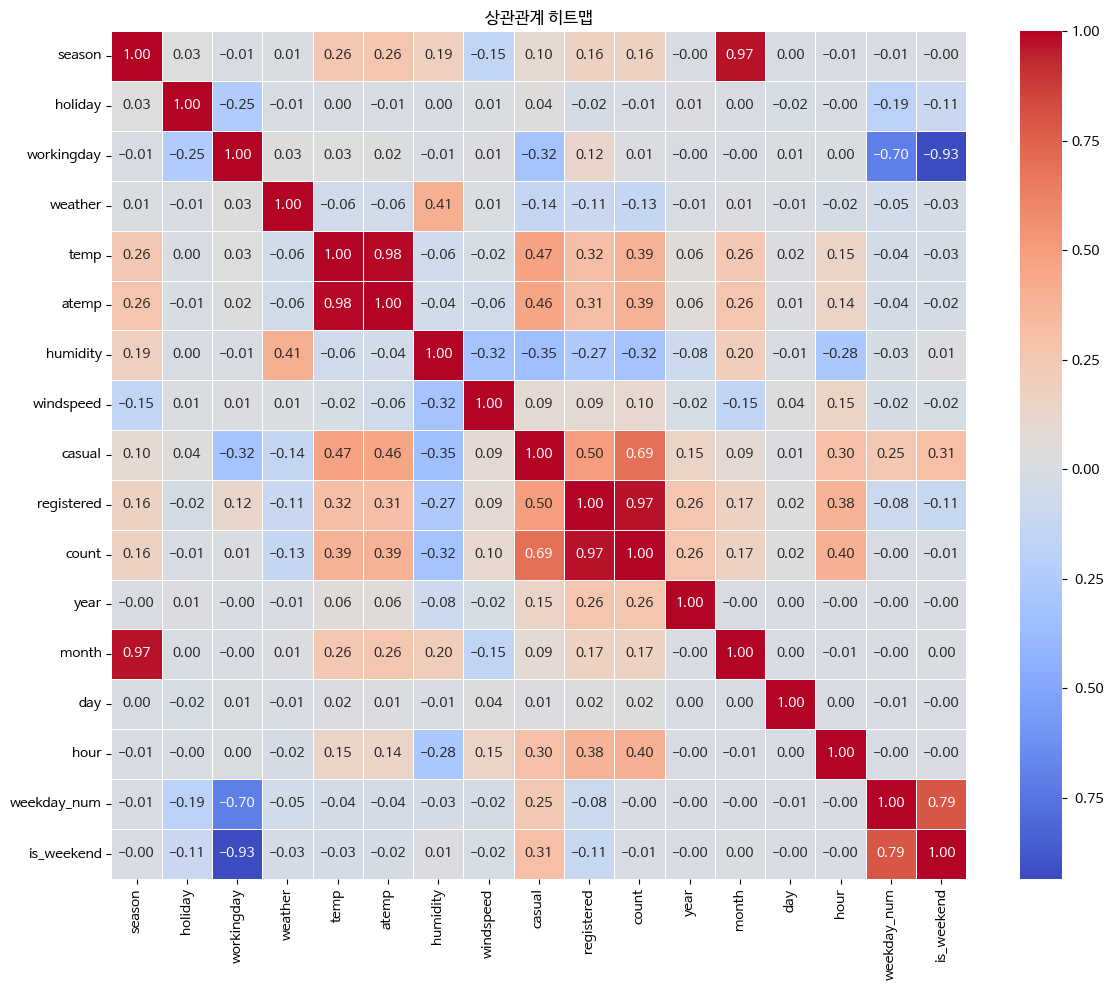

In [ ]:
num_df = df_train.select_dtypes(include="number")

# 상관행렬 계산
corr = num_df.corr(numeric_only=True)

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,         # 값 표시
            cmap='coolwarm',    # 색상 맵
            fmt=".2f",          # 소수점 2자리
            linewidths=0.5)     # 셀 간격

plt.title("상관관계 히트맵")
plt.tight_layout()
plt.show()

- season, temp, atemp, humidity, windspeed, year, month, hour이 가장 큰 영향을 받는다고 확인.
    - 따라서, 변수들이 상관관계가 없어보인다면, 이를 통해 추가적인 파생변수를 더 만드느것이 필요하다는 걸로 판단.  

## 3.  (이상치, 결측치, 중복값 분석)

### 3.1 로그변환

<Axes: xlabel='count', ylabel='Count'>

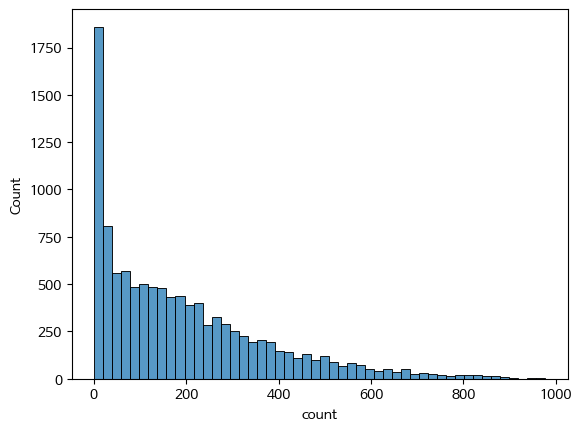

In [ ]:
# 데이터 확인
sns.histplot(df_train["count"], bins=50)

###### 📌 로그 변환과 평가 지표 (RMSE, MAE, RMSLE)

---

###### 1. 왜 로그 변환이 필요한가?
- 원래 데이터를 쓰면 모델이 큰 값에만 맞춰 학습하고 작은 값은 무시됨  
- RMSLE는 지표 계산 시 자동으로 로그를 취하기 때문에,  
  학습도 로그 변환된 값으로 해야 **학습 기준과 평가 기준이 일치**함  
- 로그 변환 → 작은 값과 큰 값을 같은 스케일에서 다룸 → 안정적 학습 가능  

---

###### 2. 간단한 예시

**(A) 원래 값 그대로 학습**  
- 실제: [1, 10, 1000]  
- 예측: [2, 12, 900]  

- RMSE ≈ **57.7**  
- RMSLE ≈ **0.26**  

👉 큰 값(1000)의 오차가 RMSE를 압도 → 평가(RMSLE)와 학습 불일치  

---

**(B) 로그 변환 후 학습**  
- 실제(log): [0.693, 2.398, 6.908]  
- 예측(log): [1.099, 2.565, 6.802]  

- RMSE ≈ **0.148**  
- RMSLE ≈ **0.148**  

👉 학습과 평가가 같은 로그 공간 → 안정적  

---

###### 3. RMSE·MAE도 로그 변환하는 게 좋을까?

- **원래 RMSE/MAE**: 절대 오차 기준 → 큰 값의 차이를 크게 봄  
- **로그 변환 후 RMSE/MAE**: 상대 오차(%) 기준 → 작은 값의 비율 차이를 크게 봄  

**예시**  
- 실제 10 vs 20 → 차이 10 (100% 증가)  
- 실제 1000 vs 1010 → 차이 10 (1% 증가)  

👉 원래 RMSE/MAE: 둘 다 “10 차이”로 동등 취급  
👉 로그 변환 RMSE/MAE: 100% vs 1% → 전자가 훨씬 크다고 평가  

---

###### 4. 언제 어떤 걸 써야 할까?

| 상황 | 적합한 방식 | 이유 |
|------|-------------|------|
| **큰 값의 절대 오차가 중요한 경우** <br> (집값, 전력 사용량, 매출액 예측 등) | 원래 값 + RMSE/MAE | 실제 손실이 절대 금액 기준으로 발생 |
| **상대적인 비율 차이가 중요한 경우** <br> (수요 예측, 주문량 예측, 개수 단위 데이터 등) | 로그 변환 + RMSE/MAE (≈ RMSLE) | 작은 값도 공정하게 반영, 큰 값 치중 방지 |
| **데이터 분포가 크고 치우친 경우** | 로그 변환 + RMSLE | 평가와 학습 기준이 일치, 안정적 학습 가능 |

---

###### 5. 핵심 한 줄 요약
- **RMSE/MAE**는 절대 차이를 보는 지표  
- **로그 변환 RMSE/MAE (또는 RMSLE)**는 상대적 차이를 보는 지표  
- 상황에 따라 둘 중 하나를 선택해야 하고,  
- **RMSLE를 쓰려면 학습 데이터도 로그 변환해야 안정적**이다

In [ ]:
# 종속변수 로그변환
df_train["count_log"] = np.log1p(df_train["count"])
df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday_num,is_weekend,count_log
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1,2.833213
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1,3.713572
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1,3.496508
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1,2.639057
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1,0.693147


### 3.2 이상치 (Windspeed)

<img src="picture1.jpg" width="500">

- 평균 8.2m/s, 최고	56.9969 m/s
- 위 이미지를 바탕으로 미국 강풍주의보 기준 (20 m/s) 이후에는 자전거가 운행이 불가하다고 판단.
- 이에 대해 두가지로 방법을 생각해봄
    - 20 넘으면 바람을 모두 20으로 가정하던지
        - 결과적으로 사람들이 20일때 자전거를 굉장히 많이 탄다!로 결과가 바뀜.
        - 오차는 줄어들지만 말이 안된다고 판단.

    - 이상치로 간주, 삭제.
        - 삭제하기로 판단.

In [ ]:
def wind_speed_limit(df):
    df = df[~(df['windspeed'] > 20)]
    return df

df_train = wind_speed_limit(df_train)
# df_test.describe().T
# df_test = wind_speed_limit(df_test) -> 테스트 데이터에도 이런걸 써야할까? -> 우리가 날린 풍속데이터 (>20 m/s 은 test 에도 있다. extrapolation 생각)

df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,9391,2012-01-03 19:36:26.220849664,2011-01-01 00:00:00,2011-07-09 01:30:00,2012-01-05 13:00:00,2012-07-07 20:30:00,2012-12-19 23:00:00,NaN
season,9391.0,2.559685,1.0,2.0,3.0,4.0,4.0,1.100697
holiday,9391.0,0.027686,0.0,0.0,0.0,0.0,1.0,0.164081
workingday,9391.0,0.677777,0.0,0.0,1.0,1.0,1.0,0.467353
weather,9391.0,1.421467,1.0,1.0,1.0,2.0,4.0,0.63008
temp,9391.0,20.447697,0.82,13.94,20.5,27.06,41.0,7.810826
atemp,9391.0,23.977042,0.76,16.665,24.24,31.06,45.455,8.361632
humidity,9391.0,63.689703,0.0,49.0,65.0,79.0,100.0,18.67333
windspeed,9391.0,10.524086,0.0,7.0015,11.0014,15.0013,19.9995,5.944827
casual,9391.0,35.318709,0.0,4.0,16.0,48.0,367.0,49.247874


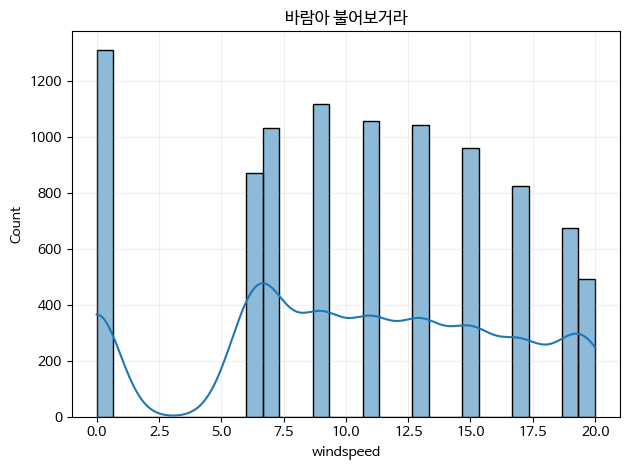

In [ ]:
sns.histplot(df_train["windspeed"], bins=30, kde=True)
plt.title("바람아 불어보거라")
plt.grid(True, alpha=0.20) # 20% 정도로 투명도로 격자를 만들기.
plt.tight_layout()
plt.show()

# 계측기의 위치에 따라 0인 데이터는 그럴  수도 있다고 판단.

### 3.3 이상치 (Humidity)

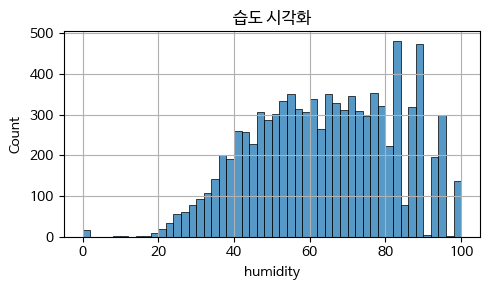

In [ ]:
# Humidity 는 상대습도와 절대습도가 있을 수 있다. 이에 대해 본 자료에서는 밝히지 않음.
# 0에서 100까지가 나올 수 있는 습도인가에 대해 알아보자.

plt.figure(figsize=(5, 3))
sns.histplot(df_train["humidity"], bins=50)
plt.title("습도 시각화")
plt.grid(True)
plt.tight_layout()
plt.show()

#### 📌 결론: 20% 미만 습도값은 이상치로 제거
    - Lawrence, M. G. (2005). The relationship between relative humidity and the dewpoint temperature in moist air: A simple conversion and applications. Bulletin of the American Meteorological Society, 86(2), 225–233. → RH의 정의와 극한 사례 설명.
    - 레퍼런스: Rogers, R. R., & Yau, M. K. (1989). A Short Course in Cloud Physics. Pergamon Press. → 절대습도 정의와 극한 조건 설명.


1. **일반적인 국가 평균 습도 분포**  
   - 🌏 온대: 60–80%  
   - 🌴 열대: 75–90%  
   - 🏜️ 사막 낮: 10–20%, 밤에는 40–50%  
   - ❄️ 극지: 절대습도는 거의 0에 가깝지만, 상대습도는 60–80% 유지  
   👉 따라서 **20% 미만의 상대습도는 자연 상태에서 매우 드문 값**임.  

2. **데이터 품질 관점**  
   - 센서 오류, 기록 누락, 극한 환경 요인으로 인해 비정상적으로 낮은 값이 발생할 수 있음  
   - 일반 국가·도시 기준 분석에서는 **노이즈로 작용할 가능성이 큼**  

3. **실무 적용성**  
   - 에너지, HVAC, 건축, 환경 데이터 분석에서는 보통 **30–80% 구간을 정상 범위**로 설정  
   - 따라서 **20% 미만 값은 이상치 처리(outlier handling)** 가 합리적  

---

✅ **최종 결론:**  
20% 미만의 상대습도는 극히 예외적인 경우이거나 오류일 가능성이 높으므로, **일반적인 기후·환경 데이터 분석에서는 이상치로 간주해 제거하는 것이 타당하다.**

<Axes: xlabel='humidity', ylabel='Count'>

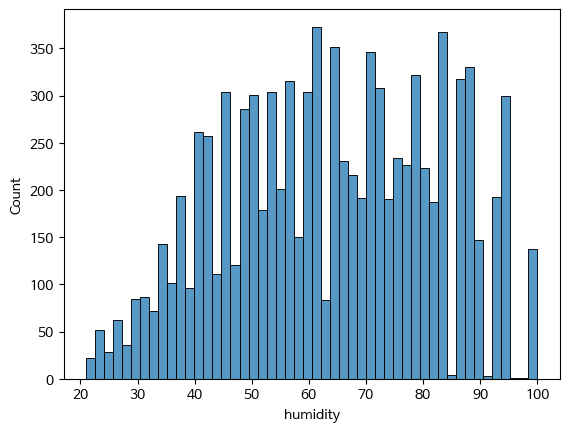

In [ ]:
df_train=df_train[~(df_train['humidity'] <= 20)]  # 20미만 제거

sns.histplot(df_train["humidity"], bins=50)

### 3.4. 이상치 (whether)

* 본 데이터에서는 **1, 2, 3월 → 봄 / 4, 5, 6월 → 여름 / 7, 8, 9월 → 가을**로 규정하고 있음.

  * 기상학적 계절 (Meteorological Seasons)

    - **북반구**에서는 보통 **3월, 4월, 5월**이 봄으로 정의됨  
      ([Wikipedia](https://en.wikipedia.org/wiki/Spring_%28season%29))

    - **남반구**에서는 그 반대 개념으로, **9월, 10월, 11월**이 봄으로 간주됨  
      ([Wikipedia](https://en.wikipedia.org/wiki/Spring_%28season%29))

    - 따라서 **1, 2, 3월을 봄으로 여기는 나라는 공식적인 기준에는 없음**.

    - 그러므로, **우리가 사용하는 데이터의 계절 구분 방식을 수정할 필요가 있음**.

In [ ]:
df_train[df_train['season']==1].head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday_num,is_weekend,count_log
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1,2.833213
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1,3.713572
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1,3.496508
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1,2.639057
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1,0.693147


In [ ]:
def season_change(month):
    if month in [3,4,5]:
        return 1
    elif month in [6,7,8]:
        return 2
    elif month in [9,10,11]:
        return 3
    else:
        return 4

df_train['season'] = df_train['month'].apply(season_change)
df_test['season'] = df_test['month'].apply(season_change)

### 3.5 weather ==4  
- weather==4는 매우 희귀 → 모델에선 불균형 주의 (10개 미만)
- 눈올때 공용자전거를 타는 것도 이상한 일이야. 그러니 없애버리자

In [ ]:
df=df_train[~(df_train['weather']==4)]

## 4. 드릴다운

### 4-1. 시간대별 자전거 대여량

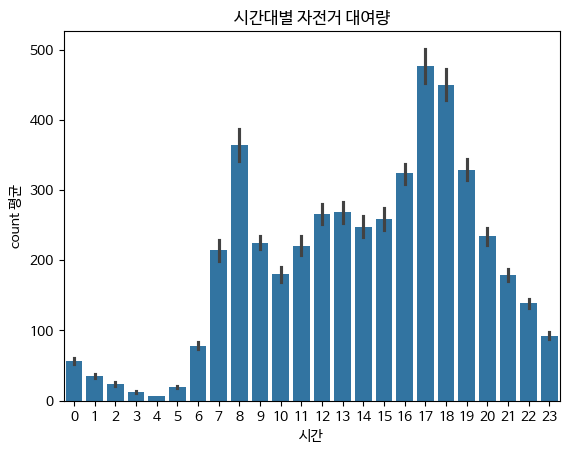

<Axes: xlabel='hour', ylabel='count'>

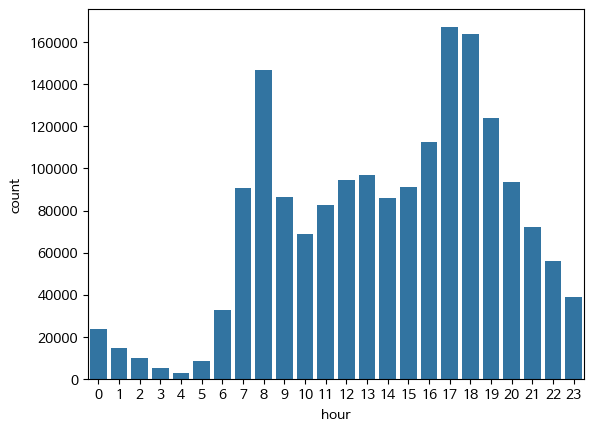

In [ ]:
sns.barplot(data=df_train, x="hour", y="count", estimator=np.mean)

plt.title("시간대별 자전거 대여량")
plt.xlabel("시간")
plt.ylabel("count 평균")
plt.show()

sns.barplot(data=df_train, x="hour", y="count", ci=None, estimator=np.sum)

- 비슷하다. 그리고 출퇴근 시간에 양이 많고, 새벽에는 이용자들이 급감한다.

### 4-2. 월별 자전거 대여량

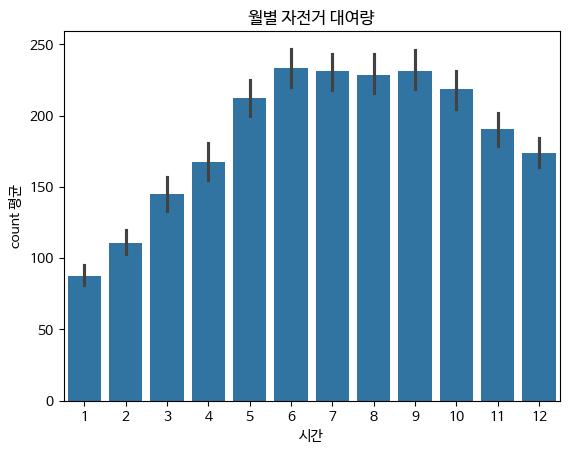

<Axes: xlabel='month', ylabel='temp'>

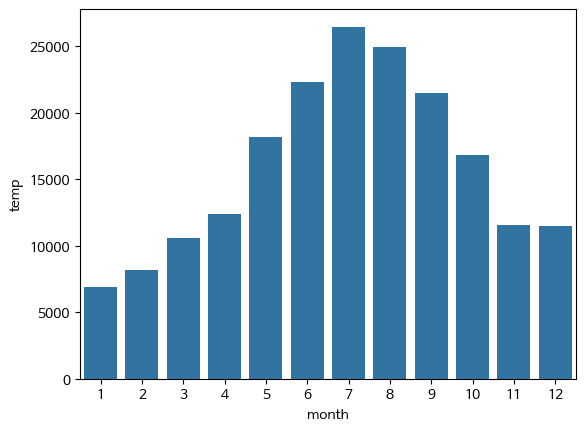

In [ ]:
sns.barplot(data=df_train, x="month", y="count", estimator=np.mean)

plt.title("월별 자전거 대여량")
plt.xlabel("시간")
plt.ylabel("count 평균")
plt.show()

sns.barplot(data=df_train, x="month", y="temp", ci=None, estimator=np.sum)

 - 6~9월에 대여량이 많다. -> 온도와 연관성이 큼.

### 4.3 계절별 대여량

<Axes: xlabel='season', ylabel='count'>

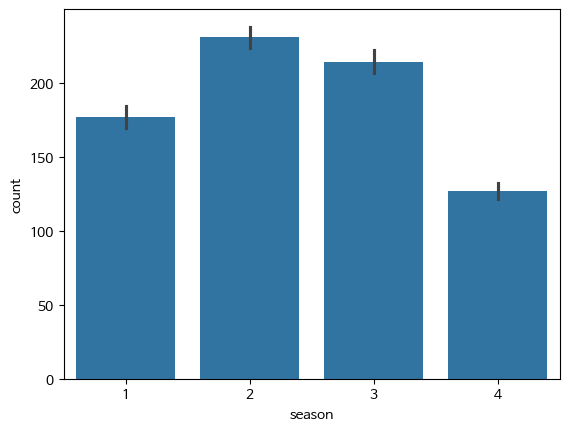

In [ ]:
sns.barplot(data=df_train, x="season", y="count", estimator=np.mean)

- 관계가 크게 없는 것으로 나옴. 이는 추가 파라미터 수정이 필요함.

### 4.4 업무일 혹은 휴일?

| 변수명            | 자료형 | 설명                              |
| -------------- | --- | ------------------------------- |
| **holiday**    | int | 공휴일 여부 <br> (0: 평일, 1: 공휴일)     |


<Axes: xlabel='holiday', ylabel='count'>

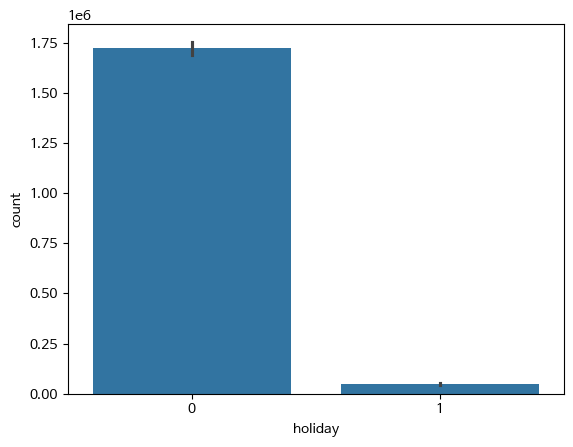

In [ ]:
sns.barplot(data=df_train, x="holiday", y="count", estimator=np.sum)

👉🏼평일이 훨씬 이용자가 많음.

### 4.5 평일 혹은 주말

| 변수명            | 자료형 | 설명                              |
| -------------- | --- | ------------------------------- |
| **workingday** | int | 근무일 여부 <br> (0: 주말/공휴일, 1: 근무일) |

<Axes: xlabel='workingday', ylabel='count'>

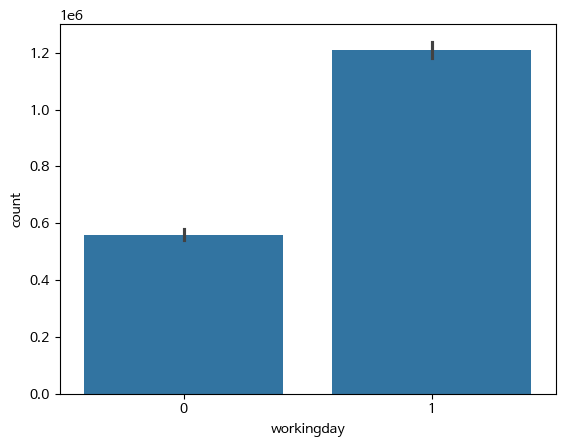

In [ ]:
sns.barplot(data=df_train, x="workingday", y="count", estimator=np.sum)

👉🏼근무일이 훨씬 이용자가 많음.

### 4.6 요일별 평균

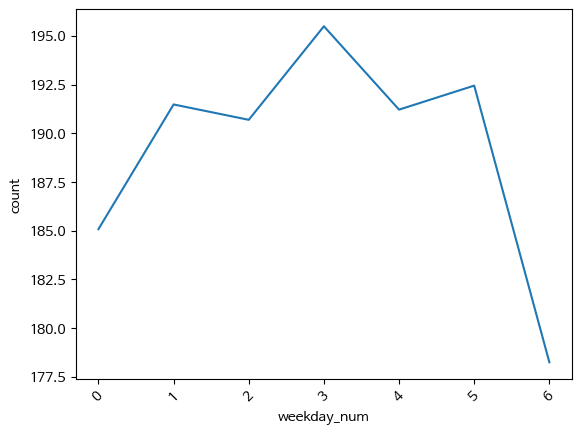

In [ ]:
sns.lineplot(data=df_train, x="weekday_num", y="count", estimator=np.mean, ci=None)
plt.xticks(rotation=45)
plt.show()

In [ ]:
큰 차이는 없긴해. (이렇게 되면 평일과 주말의 sum 차이는 단순 평일이 더 많기 떄문에 sum 이 늘어난 이유일 수 있음.

SyntaxError: invalid syntax (3124478505.py, line 1)

### 4.7 풍속별 대여량

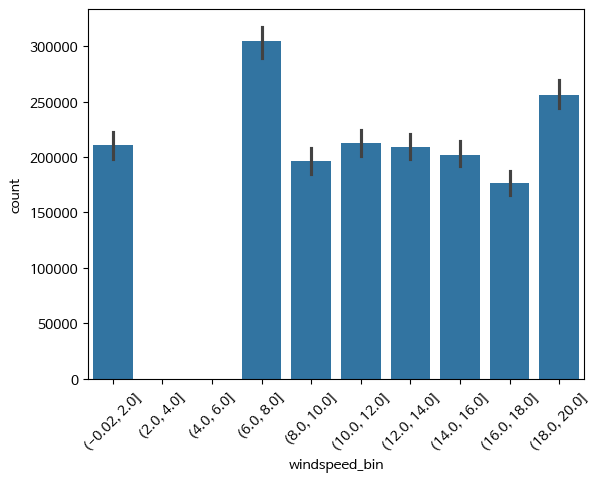

In [ ]:
df_train["windspeed_bin"] = pd.cut(df_train["windspeed"], bins=10)
sns.barplot(data=df_train, x="windspeed_bin", y="count", estimator=np.sum)
plt.xticks(rotation=45)
plt.show()

- 이상하게도 2 ~ 6까지 풍속을 가지는 데이터는 없음. 2
    - 날려버련, 20~60의데이터는 어쩌면, 측정 및 데이터의 오류로잘못표시된 값일 수도 있다. (*10^-1 필요)

- 관계가 크게 없는 것으로 나옴. 이는 추가 파라미터 수정이 필요함.(3차 모델링)

### 4.8 온도와 대여량

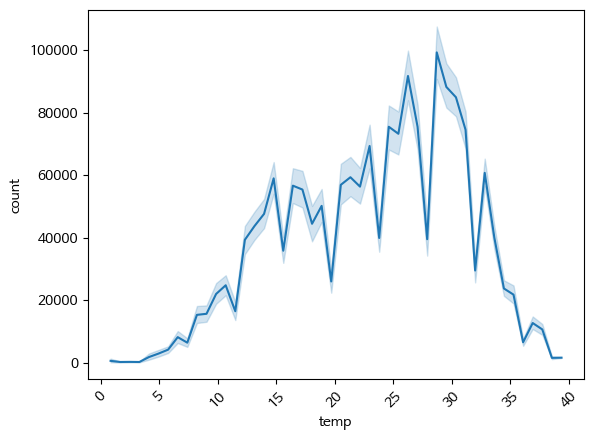

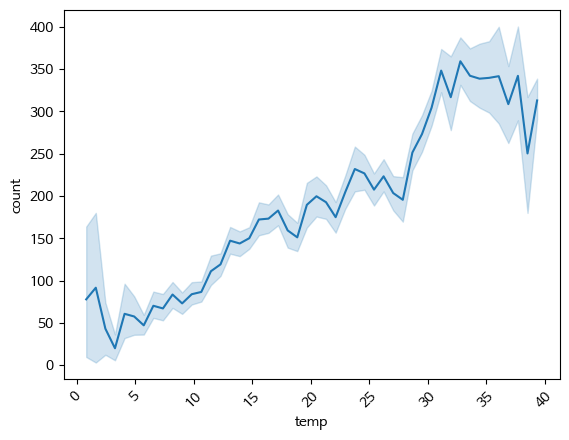

In [ ]:
sns.lineplot(data=df_train, x="temp", y="count", estimator=np.sum)
plt.xticks(rotation=45)
plt.show()

sns.lineplot(data=df_train, x="temp", y="count", estimator=np.mean)
plt.xticks(rotation=45)
plt.show()

평균 대여량은 온도가 높을때 많은 것같지만, 총합은 온도가올라가면 낮아진다.

In [ ]:
df_temp = df_train[df_train["temp"] < 5]

# 확인
df_temp.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday_num,is_weekend,count_log,windspeed_bin
73,2011-01-04 05:00:00,4,0,1,1,4.92,7.575,68,7.0015,0,4,4,2011,1,4,5,1,0,1.609438,"(6.0, 8.0]"
74,2011-01-04 06:00:00,4,0,1,1,4.92,7.575,74,7.0015,0,36,36,2011,1,4,6,1,0,3.610918,"(6.0, 8.0]"
75,2011-01-04 07:00:00,4,0,1,1,4.92,7.575,74,8.9981,2,92,94,2011,1,4,7,1,0,4.553877,"(8.0, 10.0]"
181,2011-01-08 20:00:00,4,0,0,1,4.92,6.060,36,16.9979,0,28,28,2011,1,8,20,5,1,3.367296,"(16.0, 18.0]"
189,2011-01-09 04:00:00,4,0,0,1,3.28,4.545,53,12.9980,0,1,1,2011,1,9,4,6,1,0.693147,"(12.0, 14.0]"


### 4.9 Humidity (습도)

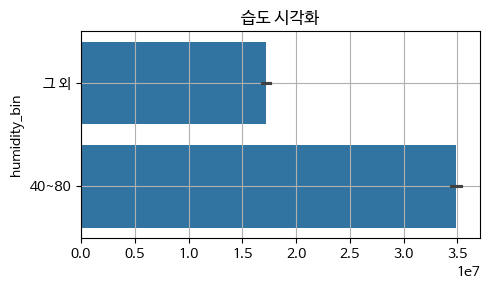

In [ ]:
df_train["humidity_bin"] = np.where(
    (df_train["humidity"] >= 40) & (df_train["humidity"] <= 80),
    "40~80",
    "그 외"
)


plt.figure(figsize=(5, 3))
sns.barplot(df_train["humidity_bin"], estimator=np.sum)
plt.title("습도 시각화")
plt.grid(True)
plt.tight_layout()
plt.show()



## 5. 모델링  

### 1) 1차 모델링 (Base Model)

In [ ]:
df_train.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'weekday_num', 'is_weekend',
       'count_log', 'windspeed_bin', 'humidity_bin'],
      dtype='object')

In [ ]:
# 모델링 타겟 변수 지정

feature_1 = ['season',
             'holiday',
             'workingday',
             'weather',
             'temp',
             'atemp',
             'humidity',
             'windspeed',
             'weekday_num',
             'hour',
             'month',
             'year']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline




# 데이터 지정
X1_train = df_train[feature_1]
y1_train = df_train["count_log"]

# 학습을 위해 데이터 분할
# 즉, 데이터 개수가 N개라면
## X1_train, y1_train → 0.7 × N
## X1_val, y1_val → 0.3 × N

X1_train, X1_val, y1_train, y1_val=train_test_split(X1_train, y1_train, test_size=0.3, random_state=42)



In [ ]:
# 선형 회귀모델 훈련
model_lr = LinearRegression(n_jobs=1)
model_lr.fit(X1_train, y1_train)

# 종속변수 로그 역변환
y1_pred_log = model_lr.predict(X1_val)
y1_pred = np.expm1(y1_pred_log)
y1_true = np.expm1(y1_val)

print(y1_pred)

[ 78.28686826 315.04001818  87.46245987 ... 145.06203772  23.03456305
 217.10166733]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y1_true, y1_pred)
rmsle = np.sqrt(mean_squared_log_error(y1_true, y1_pred))

print (mse)
print (rmsle)

25047.918273673215
1.0127573814459245


### 2) 2차 모델링
    - 앞까지는 모든 변수들을 떄려 넣어 최적화했다면, Optimized 된 변수를 추가하여 회귀를 해보려고 한다. (Humidity와 weather)

#### 🔹 근거 (Reference 기반)

##### 1. ASHRAE (American Society of Heating, Refrigerating and Air-Conditioning Engineers)
- 실내 환경 기준(**ASHRAE Standard 55**)에서는 사람들이 쾌적하게 느끼는 상대습도(RH) 범위를 **30~60%**로 제안  
- 30% 미만은 건조 → 피부·호흡기 문제  
- 60% 이상은 곰팡이·세균 번식 위험  
- 📖 Reference: *ASHRAE Standard 55-2020, Thermal Environmental Conditions for Human Occupancy*

---

##### 2. WHO (World Health Organization)
- 실내 습도가 **40~60%**일 때 인체 건강상 가장 바람직하다고 언급  
- 특히 호흡기 바이러스(예: 인플루엔자, 코로나) 전파가 40% 이하에서 활발하다는 연구 결과 존재  
- 📖 Reference: *WHO guidelines for indoor air quality: dampness and mould, 2009*

---

##### 3. 환경부 및 국내 연구 자료
- 국내 실내공기질 권장 기준에서도 **40~60%를 쾌적 습도**로 제시  
- 다만 실제 데이터에서는 **20% 근처까지 습도가 내려가는 경우도 존재**  
- 따라서 분석에서는 **20~60%를 상대적 쾌적 구간**으로 설정하는 경우가 많음  
- 📖 Reference: *환경부, 「실내공기질 관리 가이드라인」, 2018*

👉🏼 40~80 정도의 구간을 타기 좋은 구간이라고 나눔.

In [ ]:
def add_ideal_weather(df):
    # 습도 20~60% → 이상적(1), 60~100% → 비이상적(0)
    df['humidity_comfort'] = df['humidity'].map(
        lambda x: 1 if 24 <= x <= 80 else 0
    )

    # ✅ 날씨 단순화 (맑음, 구름 조금 → 1, 그 외 → 0)
    df['weather_ideal'] = df['weather'].map(lambda x: 1 if x in [1, 2] else 0)

    return df

In [ ]:
# 함수 적용
df_train = add_ideal_weather(df_train)
df_test = add_ideal_weather(df_test)

# 모델링 타깃 변수 지정

feature_2 = ['season',
             'holiday',
             'workingday',
             'weather',
             'temp',
             'atemp',
             'humidity',
             'windspeed',
             'weekday_num',
             'hour',
             'month',
             'year',
            'humidity_comfort',
             'weather_ideal']

In [ ]:
X2_train = df_train[feature_2]         # 입력 변수들 (feature set)
y2_train = df_train["count_log"]       # 목표 변수 (타깃)

In [ ]:
X2_train, X2_val, y2_train, y2_val=train_test_split(X2_train, y2_train, test_size=0.3, random_state=42)

In [ ]:
# 선형 회귀모델 훈련
model_lr = LinearRegression(n_jobs=1)
model_lr.fit(X2_train, y2_train)

# 종속변수 로그 역변환
y2_pred_log = model_lr.predict(X2_val)
y2_pred = np.expm1(y2_pred_log)
y2_true = np.expm1(y2_val)

print(y1_pred)

[ 78.28686826 315.04001818  87.46245987 ... 145.06203772  23.03456305
 217.10166733]


In [ ]:
mse = mean_squared_error(y1_true, y1_pred)
rmsle = np.sqrt(mean_squared_log_error(y1_true, y1_pred))

print (mse)
print (rmsle)

25047.918273673215
1.0127573814459245


### 3) 3차 모델링

 - 위에는 LinearRegression 맞 썼다. 이에 대해 추가적인 회귀모델을 푸는 방법 (Ridge, Lasso, ElasticNet, Polynomial_2nd, Polynomial 3rd) 중에서 비교해보자

#### 회귀 모델 비교 접근 방법

##### 모델링 1. Baseline 모델

* **LinearRegression**

  * 가장 기본적인 선형 회귀
  * 규제가 없어 단순 성능 비교의 기준점으로 활용

추가적으로 다음과 같은 모델링을 통해서 머신러닝해보자!

##### 2️⃣ 규제(Regularization) 기반 모델

* **Ridge**

  * L2 규제 적용 → 계수 크기를 줄여 과적합 방지
* **Lasso**

  * L1 규제 적용 → 불필요한 변수 자동 제거 (Feature Selection 효과)
* **ElasticNet**

  * L1 + L2 혼합 규제 → Ridge와 Lasso 장점을 모두 활용

##### 3️⃣ 다항식 변환 기반 모델

* **Polynomial\_2nd**

  * 2차 다항식 변환 → 비선형 관계 일부 학습 가능
* **Polynomial\_3rd**

  * 3차 다항식 변환 → 더 복잡한 곡선 관계 반영

##### 4️⃣ 평가 지표

* **MAE (Mean Absolute Error)**
* **MSE (Mean Squared Error)**
* **RMSE (Root Mean Squared Error)**
* **RMSLE (Root Mean Squared Log Error)**
* **R² (Coefficient of Determination)**


In [ ]:
X3_train = df_train[feature_2]         # 입력 변수들 (feature set)
y3_train = df_train["count_log"]       # 목표 변수 (타깃)

In [ ]:
X3_train, X3_val, y3_train, y3_val=train_test_split(X3_train, y3_train, test_size=0.3, random_state=42)

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=10),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.1),
    "Polynomial_2nd": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Polynomial_3rd": make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
}

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score


results_1 = []

for name, model in models.items():
    model.fit(X3_train, y3_train)
    y3_pred_log = model.predict(X3_val)
    y3_pred = np.expm1(y3_pred_log)
    y3_true = np.expm1(y3_val)

    mae = mean_absolute_error(y3_true, y3_pred)
    mse = mean_squared_error(y3_true, y3_pred)
    rmse = np.sqrt(mean_squared_error(y3_true, y3_pred))
    rmsle = np.sqrt(mean_squared_log_error(y3_true, y3_pred))
    r2 = r2_score(y3_true, y3_pred)

    results_1.append({
        'model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'RMSLE': rmsle,
        'R2': r2
    })

In [ ]:
# 모델 결과 확인
results_1= pd.DataFrame(results_1)
results_1

# MAE,MSE,RMSE (1넘어가면 안돼!), RMSLE 가 모두 작아질수록 좋은값
# R2 는 1에 가까워질수록 좋은값

,model,MAE,MSE,RMSE,RMSLE,R2
0,LinearRegression,105.679681,2.510486e+04,158.445129,1.008330,0.220750
1,Ridge,105.677467,2.510292e+04,158.438996,1.008330,0.220811
2,Lasso,140.111572,4.065799e+04,201.638259,1.414367,-0.262016
3,ElasticNet,105.598830,2.500977e+04,158.144764,1.008727,0.223702
4,Polynomial_2nd,75.976335,1.494799e+04,122.261984,0.870094,0.536017
5,Polynomial_3rd,2121.651434,9.271702e+09,96289.675958,0.908035,-287790.735733


👉🏼 결과적으로 Polynomial_2nd가 가장 RMSLE를 작게 머신러닝했다.
    - RMSLE - 0.87 / R^2 - 0.53
👉🏼 각각의 모델들을 하나씩 보여주는 코드가 있었음.

👉🏼 강사님의 해설강의를 듣고 강사님과 비슷한 모양으로 작성 (참고: 조하나 강사님 수업)

## 6. 결과 시각화 (Feature Importance)  


## 7. 결과 생성

In [ ]:
# 데이터 지정
X_all = df_train[feature_2]
y_all_log = df_train["count_log"]     # 로그 스케일 타깃

# 테스트셋도 같은 컬럼만 사용
X_final_test = df_test[feature_2].copy()

# 학습/검증 분할
X_train, X_val, y_train_log, y_val_log = train_test_split(X_all, y_all_log, test_size=0.3, random_state=42)

# Polynomial 2차
model_poly2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

model_poly2.fit(X_train, y_train_log)

# 검증 예측
y_val_pred_log = model_poly2.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)
y_val_true = np.expm1(y_val_log)


mae  = mean_absolute_error(y_val_true, y_val_pred)
mse  = mean_squared_error(y_val_true, y_val_pred)
rmsle = np.sqrt(mean_squared_log_error(y_val_true, y_val_pred))
r2   = r2_score(y_val_true, y_val_pred)

print(f"[Poly2] MAE={mae:.3f} | RMSLE={rmsle:.3f} | R2={r2:.3f}")

# 검증 성능 확인 후, 최종 제출은 전체 데이터(X_all, y_all_log)로 재학습하여 테스트셋 예측
model_poly2.fit(X_all, y_all_log)

# === 7) 테스트 예측 → 로그 복원 ===
y_test_pred_log = model_poly2.predict(X_final_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.maximum(y_test_pred, 0)   # 안전 클리핑
print(y_test_pred[:10])  # 샘플 확인

# === 8) 제출 파일 ===
submission = pd.DataFrame({
    "datetime": df_test["datetime"],
    "count": y_test_pred.round().astype(int)
})

submission.to_csv(
    "ABC",
    index=False
)

[Poly2] MAE=75.976 | RMSLE=0.870 | R2=0.536
[ 2.37652275  5.54866511  8.28746578 11.51206192 15.99007252 19.1546333
 23.92966138 31.67831387 37.25616208 45.79157901]


# PDF 총평
*   전반적으로 매우 훌륭한 분석 보고서였어요. 가설 설정, 데이터 분석, 모델링, 인사이트 도출로 이어지는 논리적인 구조가 명확했고, 각 단계에서 내린 판단의 근거를 설득력 있게 제시해서 좋았습다. 특히 외부 자료와 도메인 지식을 활용해 풍속, 습도, 계절 변수를 합리적으로 정제한 과정이 매우 인상 깊었습니다. 또한, RMSLE 평가지표의 특성을 깊이 이해하고 타겟 변수를 로그 변환하여 모델링을 진행한 부분에서 문제 해결에 대한 높은 이해도를 엿볼 수 있었습니다.
이러한 훌륭한 분석을 바탕으로 몇 가지 추가적인 제안을 드립니다. 현재는 선형

*   모델 중심으로 분석하셨는데, 다음 단계로는 XGBoost나 LightGBM 같은 트리 기반 앙상블 모델을 적용해보시길 추천합니다. 변수 간의 복잡한 비선형 관계를 더 잘 학습하여 성능 향상을 기대할 수 있습니다. 더불어 시간대와 요일처럼 두 개 이상의 변수를 조합한 상호작용 변수를 생성하면 모델이 특정 상황의 수요 패턴을 더 세밀하게 학습하는 데 도움이 될겁니다. 현재의 분석 역량도 매우 뛰어나시며, 제안 드린 부분을 추가로 고민해보신다면 더 좋은 성능을 낼 수 있을겁니다. 수고 많으셨습니다!

